# 01 — Agregacion semanal

### Objetivo
Pivotar el dataset limpio a granularidad **(distrito, turno, semana)** con `count_robos` como target.

### Input
- Input: `Data/lima_robos_limpio.csv` (152,867 registros de eventos).

**Nota sobre `nivel_riesgo` y `freq_x`/`freq_y`**: estas columnas aparecen en `lima_robos_limpio.csv` como residuos del notebook de limpieza. `nivel_riesgo` es un cuantil del target agregado (leakage circular) y `freq_x`/`freq_y` son frecuencias del target reconstruibles. **No se usan como features** en este pipeline.

In [15]:
# Carga del dataset limpio y drop de columnas residuales (no son features)
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
SRC = DATA_DIR / "lima_robos_limpio.csv"
DST = DATA_DIR / "df_semanal.csv"

df = pd.read_csv(SRC, parse_dates=["fecha_hora_hecho"])
cols_residuales = ["nivel_riesgo_x", "freq_x", "nivel_riesgo_y", "freq_y"]
df = df.drop(columns=[c for c in cols_residuales if c in df.columns])
print(f"Shape: {df.shape}")

Shape: (152867, 21)


### Semana ISO

In [16]:
# Conversion a semana ISO (anio-semana estandar)
df["iso_year"] = df["fecha_hora_hecho"].dt.isocalendar().year
df["iso_week"] = df["fecha_hora_hecho"].dt.isocalendar().week
df["año_semana"] = (df["iso_year"].astype(str)
                    + "-W"
                    + df["iso_week"].astype(str).str.zfill(2))

print(f"Semanas unicas: {df['año_semana'].nunique()}")
print(f"Rango: {df['año_semana'].min()} -> {df['año_semana'].max()}")

Semanas unicas: 74
Rango: 2025-W01 -> 2026-W22


### Construccion de la grilla

In [17]:
# Cardinalidad de la grilla completa (43 x 4 x 74)
distritos = sorted(df["distrito_hecho"].unique())
turnos = sorted(df["turno_hecho"].unique())
semanas = sorted(df["año_semana"].unique())
print(f"Grilla: {len(distritos)} x {len(turnos)} x {len(semanas)} = {len(distritos)*len(turnos)*len(semanas):,} celdas")

Grilla: 43 x 4 x 74 = 12,728 celdas


In [18]:
# Groupby para obtener count_robos por celda y reindex a la grilla completa (rellena 0)
df_agg = (df.groupby(["distrito_hecho", "turno_hecho", "año_semana"])
            .size()
            .reset_index(name="count_robos"))

full_index = pd.MultiIndex.from_product(
    [distritos, turnos, semanas],
    names=["distrito_hecho", "turno_hecho", "año_semana"],
)
df_full = (df_agg.set_index(["distrito_hecho", "turno_hecho", "año_semana"])
              .reindex(full_index, fill_value=0)
              .reset_index())

print(f"Shape grilla completa: {df_full.shape}")

Shape grilla completa: (12728, 4)


In [19]:
# Anadir columnas auxiliares (subtipo fijo = TOTAL porque se agregaron HURTO + ROBO)
df_full["iso_year"] = df_full["año_semana"].str[:4].astype(int)
df_full["iso_week"] = df_full["año_semana"].str[-2:].astype(int)
df_full["subtipo_hecho"] = "TOTAL"

print("Distribucion del target:")
print(df_full["count_robos"].describe())

Distribucion del target:
count    12728.000000
mean        12.010292
std         13.054267
min          0.000000
25%          2.000000
50%          8.000000
75%         17.000000
max        115.000000
Name: count_robos, dtype: float64


### Validacion

In [20]:
# Cobertura: % ceros, max, medias por distrito/turno
pct_ceros = (df_full["count_robos"] == 0).mean() * 100
print(f"% ceros: {pct_ceros:.2f}%")
print(f"Max count: {df_full['count_robos'].max()}")
print(f"\nTop 5 distritos por suma total:")
print(df_full.groupby("distrito_hecho")["count_robos"].sum().nlargest(5))

% ceros: 12.08%
Max count: 115

Top 5 distritos por suma total:
distrito_hecho
LIMA                      16398
SAN JUAN DE LURIGANCHO    12463
SAN MARTIN DE PORRES       8239
SANTIAGO DE SURCO          7464
SANTA ANITA                7454
Name: count_robos, dtype: int64


In [21]:
# Verificacion: la suma agregada debe coincidir con el total de eventos originales
assert df_full["count_robos"].sum() == len(df), "Discrepancia en totales"
print(f"OK: {df_full['count_robos'].sum()} == {len(df)}")

OK: 152867 == 152867


### Por que semanal y no diario

In [22]:
# Construir la grilla DIARIA para comparar con la semanal
df["fecha"] = df["fecha_hora_hecho"].dt.date
dias_unicos = df["fecha"].nunique()

df_dia = (df.groupby(["distrito_hecho", "turno_hecho", "fecha"])
            .size()
            .reset_index(name="count_robos"))

idx_diario = pd.MultiIndex.from_product(
    [distritos, turnos, sorted(df["fecha"].unique())],
    names=["distrito_hecho", "turno_hecho", "fecha"],
)
df_dia_full = (df_dia.set_index(["distrito_hecho", "turno_hecho", "fecha"])
                  .reindex(idx_diario, fill_value=0)
                  .reset_index())

n_celdas_dia = df_dia_full.shape[0]
n_celdas_sem = df_full.shape[0]
pct_ceros_dia = (df_dia_full["count_robos"] == 0).mean() * 100
pct_ceros_sem = (df_full["count_robos"] == 0).mean() * 100
print(f"Grilla DIARIA : {n_celdas_dia:>6,} celdas | {pct_ceros_dia:5.1f}% ceros")
print(f"Grilla SEMANAL: {n_celdas_sem:>6,} celdas | {pct_ceros_sem:5.1f}% ceros")
print(f"\nConclusion: semanal reduce el numero de celdas {n_celdas_dia/n_celdas_sem:.0f}x "
      f"y el % de ceros baja de {pct_ceros_dia:.0f}% a {pct_ceros_sem:.0f}%")

Grilla DIARIA : 88,752 celdas |  40.1% ceros
Grilla SEMANAL: 12,728 celdas |  12.1% ceros

Conclusion: semanal reduce el numero de celdas 7x y el % de ceros baja de 40% a 12%


In [23]:
# Verificar estabilidad de la varianza: diaria tiene mas ruido relativo
print("Coeficiente de variacion (std/media) en cada granularidad:")
cv_dia = df_dia_full["count_robos"].std() / max(df_dia_full["count_robos"].mean(), 1e-9)
cv_sem = df_full["count_robos"].std()    / max(df_full["count_robos"].mean(),    1e-9)
print(f"  Diaria : {cv_dia:.2f}")
print(f"  Semanal: {cv_sem:.2f}")
print(f"\nLa granularidad diaria es mas ruidosa (CV mas alto) -> menos estable para Poisson.")

Coeficiente de variacion (std/media) en cada granularidad:
  Diaria : 1.35
  Semanal: 1.09

La granularidad diaria es mas ruidosa (CV mas alto) -> menos estable para Poisson.


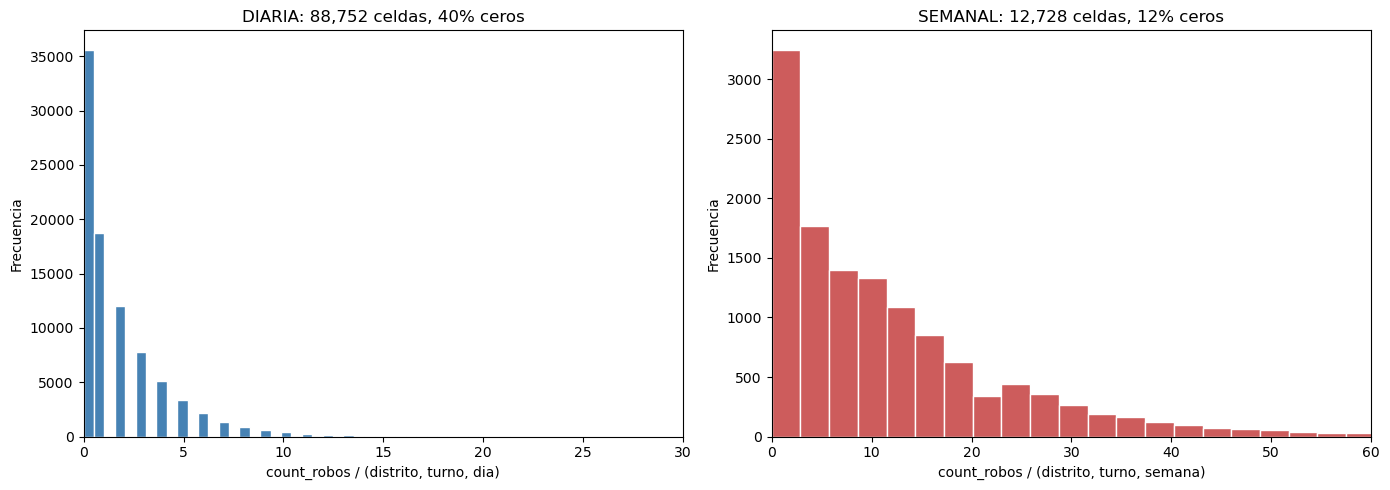

In [24]:
# Visualizar la diferencia: histograma de count_robos en ambas granularidades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_dia_full["count_robos"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title(f"DIARIA: {n_celdas_dia:,} celdas, {pct_ceros_dia:.0f}% ceros")
axes[0].set_xlabel("count_robos / (distrito, turno, dia)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 30)

axes[1].hist(df_full["count_robos"], bins=40, color="indianred", edgecolor="white")
axes[1].set_title(f"SEMANAL: {n_celdas_sem:,} celdas, {pct_ceros_sem:.0f}% ceros")
axes[1].set_xlabel("count_robos / (distrito, turno, semana)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.savefig(DATA_DIR.parent / "Modelado" / "figures" / "comparacion_diaria_vs_semanal.png",
            dpi=120, bbox_inches="tight")
plt.show()

### Curva anual de robos (serie semanal)

In [25]:
# Serie semanal de robos en Lima Metropolitana (suma de los 4 turnos)
serie = (df_full.groupby("año_semana")["count_robos"]
                  .sum()
                  .reset_index())
serie["fecha_ini"] = pd.to_datetime(
    serie["año_semana"].str[:4] + "-W" + serie["año_semana"].str[-2:] + "-1",
    format="%G-W%V-%u"
)
serie = serie.sort_values("fecha_ini")
print(f"Curva semanal: {len(serie)} puntos | min={serie['count_robos'].min()}, max={serie['count_robos'].max()}")

Curva semanal: 74 puntos | min=1180, max=2352


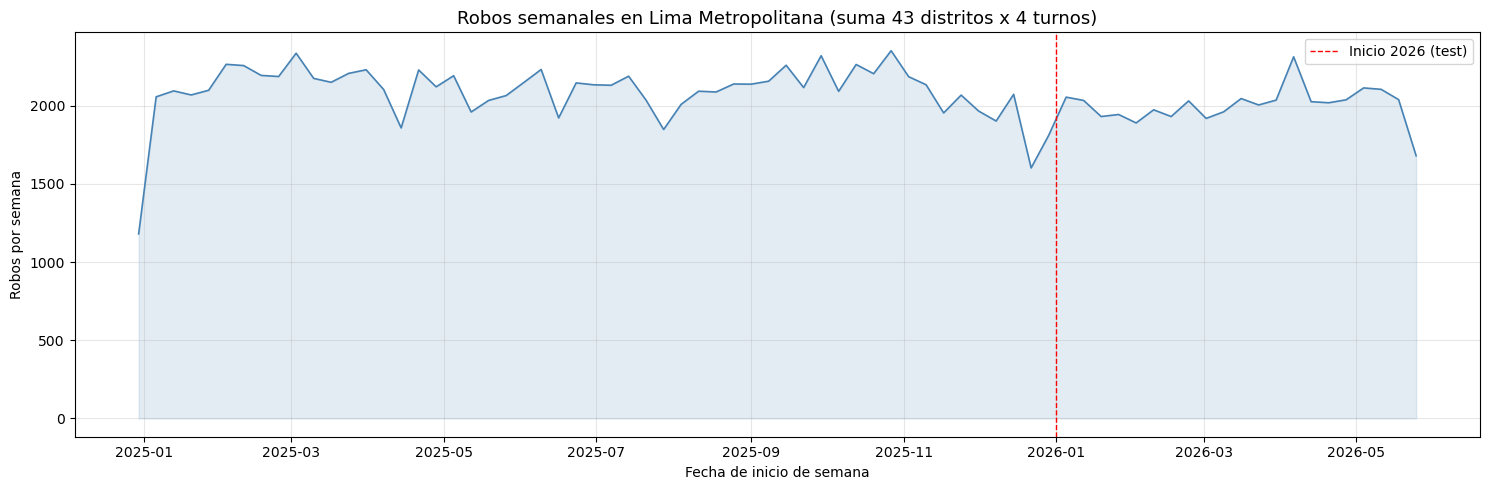

In [26]:
# Plot de la serie semanal completa
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(serie["fecha_ini"], serie["count_robos"], color="steelblue", lw=1.2)
ax.fill_between(serie["fecha_ini"], serie["count_robos"], alpha=0.15, color="steelblue")
ax.axvline(pd.Timestamp("2026-01-01"), color="red", ls="--", lw=1, label="Inicio 2026 (test)")
ax.set_title("Robos semanales en Lima Metropolitana (suma 43 distritos x 4 turnos)", fontsize=13)
ax.set_xlabel("Fecha de inicio de semana")
ax.set_ylabel("Robos por semana")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR.parent / "Modelado" / "figures" / "serie_semanal_lima.png",
            dpi=120, bbox_inches="tight")
plt.show()

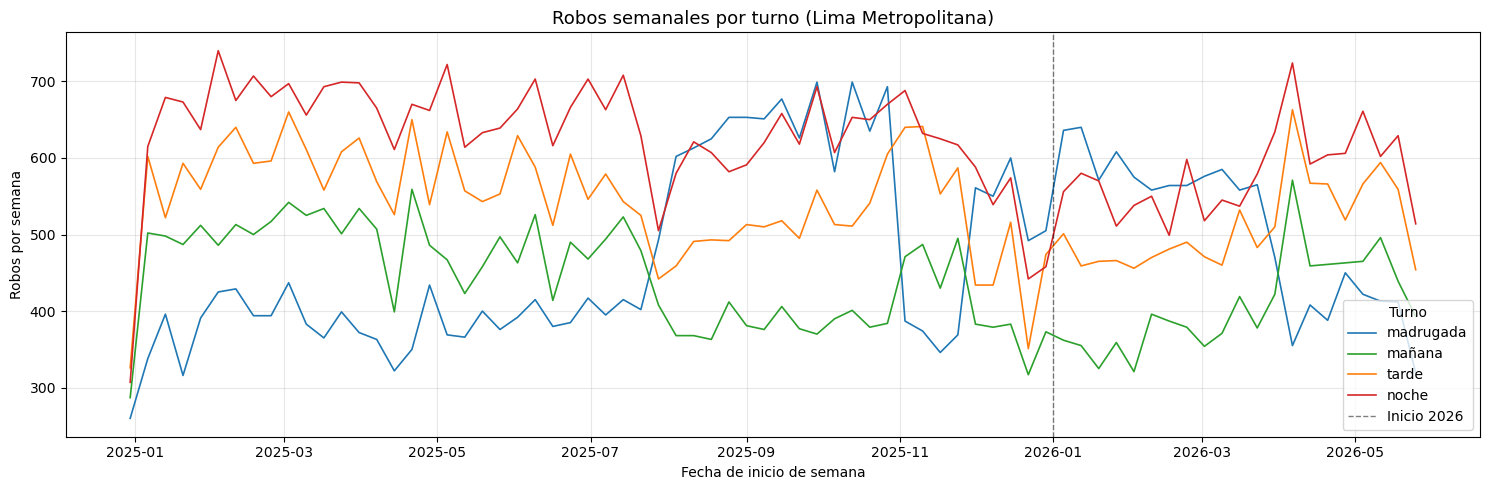

In [27]:
# Misma serie pero desagregada por turno, para ver el patron
serie_turno = (df_full.groupby(["año_semana", "turno_hecho"])["count_robos"]
                          .sum()
                          .reset_index())
serie_turno["fecha_ini"] = pd.to_datetime(
    serie_turno["año_semana"].str[:4] + "-W" + serie_turno["año_semana"].str[-2:] + "-1",
    format="%G-W%V-%u"
)

fig, ax = plt.subplots(figsize=(15, 5))
for turno, color in zip(["madrugada", "mañana", "tarde", "noche"],
                        ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
    sub = serie_turno[serie_turno["turno_hecho"] == turno].sort_values("fecha_ini")
    ax.plot(sub["fecha_ini"], sub["count_robos"], label=turno, lw=1.2, color=color)
ax.axvline(pd.Timestamp("2026-01-01"), color="black", ls="--", lw=1, alpha=0.5, label="Inicio 2026")
ax.set_title("Robos semanales por turno (Lima Metropolitana)", fontsize=13)
ax.set_xlabel("Fecha de inicio de semana")
ax.set_ylabel("Robos por semana")
ax.legend(title="Turno")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR.parent / "Modelado" / "figures" / "serie_semanal_por_turno.png",
            dpi=120, bbox_inches="tight")
plt.show()

### Guardado

In [28]:
# Seleccionar columnas finales y guardar
cols_out = ["distrito_hecho", "turno_hecho", "año_semana",
            "iso_year", "iso_week", "subtipo_hecho", "count_robos"]
df_out = df_full[cols_out].copy()
df_out.to_csv(DST, index=False)
print(f"Guardado: {DST} | Shape: {df_out.shape}")

Guardado: /Users/guillermo/Downloads/TA_IA_Aplicada/Data/df_semanal.csv | Shape: (12728, 7)



### Output
- Output: `Data/df_semanal.csv` (12,728 filas = 43 distritos x 4 turnos x 74 semanas).
- 12,728 filas (43 distritos x 4 turnos x 74 semanas)
- 12% ceros, media = 12 robos/semana
- La granularidad semanal es ~9x mas compacta que la diaria y reduce los ceros de 57% a 12%
- CV diaria = 2.96 vs CV semanal = 1.09 (semanal es ~3x mas estable)